# RetailRocket Exploratory Data Analysis

This notebook performs a reproducible exploratory analysis of the standard RetailRocket Kaggle dataset, uses colour-blind-friendly plots, and saves summary tables.

(Please use python version 3.12.10)

In [12]:
%pip install -q pandas matplotlib numpy openpyxl

Note: you may need to restart the kernel to use updated packages.


## 1. Set paths


In [ ]:
from pathlib import Path

# Path object pointing to the directory that contains the input dataset files.
DATA_DIR = Path("input")

# Path object pointing to the directory where dataset audit artefacts will be written.
OUTPUT_DIR = Path("output/dataset_audit")

## 2. Imports and plotting style


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configure default plotting parameters for figure clarity and consistency.
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 160
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

# Reusable colour definitions applied across visual outputs.
PALETTE = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "yellow": "#F0E442",
    "sky": "#56B4E9",
    "black": "#000000",
    "grey": "#7F7F7F",
}

# Event-specific colours used to distinguish interaction types in charts.
EVENT_COLOURS = {
    "view": PALETTE["blue"],
    "addtocart": PALETTE["orange"],
    "transaction": PALETTE["green"],
}

# Explicit weekday ordering used where chronological weekday presentation is required.
WEEKDAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Ensure the output directory structure exists before saving audit artefacts.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "figures").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "tables").mkdir(parents=True, exist_ok=True)

## 3. Load the raw CSV files


In [ ]:
# Load the main event log with explicit dtypes for consistent parsing.
events = pd.read_csv(
    DATA_DIR / "events.csv",
    dtype={"visitorid": "int64", "event": "category", "itemid": "int64"},
)

# Convert the event timestamp from Unix milliseconds to timezone-aware UTC.
events["timestamp"] = pd.to_datetime(events["timestamp"], unit="ms", utc=True)

# Parse transaction identifiers as nullable integers to preserve missing values.
events["transactionid"] = pd.to_numeric(
    events["transactionid"],
    errors="coerce",
).astype("Int64")

# Load both item property files, then combine them into one unified table.
properties = pd.concat(
    [
        pd.read_csv(
            DATA_DIR / "item_properties_part1.csv",
            dtype={
                "itemid": "int64",
                "property": "string",
                "value": "string",
            },
        ),
        pd.read_csv(
            DATA_DIR / "item_properties_part2.csv",
            dtype={
                "itemid": "int64",
                "property": "string",
                "value": "string",
            },
        ),
    ],
    ignore_index=True,
)

# Convert property timestamps from Unix milliseconds to timezone-aware UTC.
properties["timestamp"] = pd.to_datetime(
    properties["timestamp"],
    unit="ms",
    utc=True,
)

# Load the category hierarchy table.
category_tree = pd.read_csv(DATA_DIR / "category_tree.csv")

# Convert category identifiers to nullable integers for safe numeric handling.
category_tree["categoryid"] = pd.to_numeric(
    category_tree["categoryid"],
    errors="coerce",
).astype("Int64")

# Convert parent category identifiers to nullable integers.
category_tree["parentid"] = pd.to_numeric(
    category_tree["parentid"],
    errors="coerce",
).astype("Int64")

# Store the event label as string for easier grouping and plotting.
events["event_str"] = events["event"].astype(str)

# Extract the calendar date for daily-level aggregations.
events["event_date"] = events["timestamp"].dt.date

# Extract the year-month label for monthly trend summaries.
events["event_month"] = events["timestamp"].dt.to_period("M").astype(str)

# Derive ordered weekday names so plots and summaries follow calendar order.
events["weekday_name"] = pd.Categorical(
    events["timestamp"].dt.day_name(),
    categories=WEEKDAY_ORDER,
    ordered=True,
)

# Extract the hour of day for intraday activity analysis.
events["event_hour"] = events["timestamp"].dt.hour.astype("int64")

# Assign an ordinal priority so event types can be ranked by interaction strength.
events["event_priority"] = (
    events["event_str"]
    .map({"view": 0, "addtocart": 1, "transaction": 2})
    .fillna(99)
    .astype(int)
)

# Return the dimensions of the three core input tables.
events.shape, properties.shape, category_tree.shape

C:\Users\pippa\AppData\Local\Temp\ipykernel_7336\4045693701.py:23: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  events["event_month"] = events["timestamp"].dt.to_period("M").astype(str)


((2756101, 11), (20275902, 4), (1669, 2))

## 4. Core summary tables


In [ ]:
def build_latest_property_map(
    properties: pd.DataFrame,
    property_name: str,
    value_name: str,
) -> pd.DataFrame:
    """
    Build a latest-value lookup table for a given item property.

    The input is filtered to a single property, sorted by item and timestamp,
    and reduced to the most recent value per item. The resulting value column
    is then renamed to the supplied output name.

    Args:
        properties: Item properties table containing at least ``itemid``,
            ``property``, ``timestamp``, and ``value`` columns.
        property_name: Property identifier to filter for.
        value_name: Output column name for the selected property values.

    Returns:
        A DataFrame containing ``itemid`` and the renamed latest-value column.
    """
    # Keep only the requested property and the columns needed to identify the
    # most recent value for each item.
    subset = properties.loc[
        properties["property"] == property_name,
        ["itemid", "timestamp", "value"],
    ].copy()

    # Sort by item and time so the final duplicate kept per item is the latest
    # recorded value.
    subset = subset.sort_values(["itemid", "timestamp"]).drop_duplicates(
        "itemid",
        keep="last",
    )

    # Rename the generic value column to a descriptive output column name.
    subset = subset.rename(columns={"value": value_name})

    # Return only the item identifier and the derived latest-value column.
    return subset[["itemid", value_name]]


# Extract the latest known category identifier for each item.
latest_category = build_latest_property_map(
    properties,
    "categoryid",
    "categoryid_latest",
)

# Extract the latest raw price value for each item.
latest_price = build_latest_property_map(
    properties,
    "790",
    "price_raw",
)

# Convert raw price values to numeric form where possible.
latest_price["price_numeric"] = pd.to_numeric(
    latest_price["price_raw"],
    errors="coerce",
)

# Create a compact summary of the core input tables used in the analysis.
dataset_summary = pd.DataFrame(
    [
        {
            "table_name": "events",
            "rows": int(len(events)),
            "unique_visitors": int(events["visitorid"].nunique()),
            "unique_items": int(events["itemid"].nunique()),
            "date_start_utc": str(events["timestamp"].min()),
            "date_end_utc": str(events["timestamp"].max()),
        },
        {
            "table_name": "item_properties_combined",
            "rows": int(len(properties)),
            "unique_items": int(properties["itemid"].nunique()),
            "unique_properties": int(properties["property"].nunique()),
            "date_start_utc": str(properties["timestamp"].min()),
            "date_end_utc": str(properties["timestamp"].max()),
        },
        {
            "table_name": "category_tree",
            "rows": int(len(category_tree)),
            "unique_categories": int(category_tree["categoryid"].nunique()),
            "non_null_parent_links": int(category_tree["parentid"].notna().sum()),
            "root_categories": int(category_tree["parentid"].isna().sum()),
        },
    ]
)

# Count each event type and store the result in a tidy tabular form.
event_type_counts = (
    events["event_str"]
    .value_counts()
    .rename_axis("event")
    .reset_index(name="count")
)

# Calculate percentage share of each event type relative to the full event set.
event_type_counts["share_pct"] = (
    event_type_counts["count"] / event_type_counts["count"].sum() * 100
).round(2)

# Display the dataset-level summary table.
dataset_summary

,table_name,rows,unique_visitors,unique_items,date_start_utc,date_end_utc,unique_properties,unique_categories,non_null_parent_links,root_categories
0,events,2756101,1407580.0,235061.0,2015-05-03 03:00:04.384000+00:00,2015-09-18 02:59:47.788000+00:00,NaN,NaN,NaN,NaN
1,item_properties_combined,20275902,NaN,417053.0,2015-05-10 03:00:00+00:00,2015-09-13 03:00:00+00:00,1104.0,NaN,NaN,NaN
2,category_tree,1669,NaN,NaN,NaN,NaN,NaN,1669.0,1644.0,25.0


NaN values in the dataset summary table were retained as indicators that a metric was not applicable to a given source table, rather than evidence of missing raw data. For presentation purposes, these values can be shown as “N/A”.

## 5. Save additional tables


In [ ]:
# Count events per day and event type, then reshape to wide format for
# time-series comparison across interaction types.
daily_event_counts_by_type = (
    events.groupby(["event_date", "event_str"]).size().reset_index(name="count")
    .pivot(index="event_date", columns="event_str", values="count")
    .fillna(0)
    .reset_index()
)

# Aggregate monthly activity to summarise overall volume, visitor breadth,
# and item breadth over time.
monthly_activity_summary = (
    events.groupby("event_month")
    .agg(
        events=("event_str", "size"),
        unique_visitors=("visitorid", "nunique"),
        unique_items=("itemid", "nunique"),
    )
    .reset_index()
)

# Count the total number of events generated by each visitor.
visitor_events = (
    events.groupby("visitorid").size().rename("events_per_visitor").reset_index()
)

# Count the total number of events associated with each item.
item_events = events.groupby("itemid").size().rename("events_per_item").reset_index()


def qstats(series: pd.Series) -> pd.DataFrame:
    """
    Compute a compact summary of a numeric distribution.

    Non-numeric values are coerced to missing values and removed before the
    summary statistics are calculated.

    Args:
        series: Input series containing numeric or numeric-like values.

    Returns:
        A one-row DataFrame containing count, mean, median, 90th percentile,
        95th percentile, and maximum value.
    """
    # Convert values to numeric form and discard missing or invalid entries.
    s = pd.to_numeric(series, errors="coerce").dropna()

    # Return the summary statistics in a tabular one-row format.
    return pd.DataFrame(
        [{
            "count": int(s.shape[0]),
            "mean": float(s.mean()),
            "median": float(s.median()),
            "p90": float(s.quantile(0.90)),
            "p95": float(s.quantile(0.95)),
            "max": float(s.max()),
        }]
    )


# Summarise how many events are typically generated per visitor.
visitor_activity_distribution_summary = qstats(visitor_events["events_per_visitor"])

# Summarise how many events are typically associated with each item.
item_activity_distribution_summary = qstats(item_events["events_per_item"])

# Save the high-level dataset summary table.
dataset_summary.to_csv(OUTPUT_DIR / "tables" / "dataset_summary.csv", index=False)

# Save event-type frequencies and percentage shares.
event_type_counts.to_csv(OUTPUT_DIR / "tables" / "event_type_counts.csv", index=False)

# Save the daily event-by-type activity table.
daily_event_counts_by_type.to_csv(
    OUTPUT_DIR / "tables" / "daily_event_counts_by_type.csv",
    index=False,
)

# Save the monthly activity summary table.
monthly_activity_summary.to_csv(
    OUTPUT_DIR / "tables" / "monthly_activity_summary.csv",
    index=False,
)

# Save the visitor activity distribution summary.
visitor_activity_distribution_summary.to_csv(
    OUTPUT_DIR / "tables" / "visitor_activity_distribution_summary.csv",
    index=False,
)

# Save the item activity distribution summary.
item_activity_distribution_summary.to_csv(
    OUTPUT_DIR / "tables" / "item_activity_distribution_summary.csv",
    index=False,
)

# Preview the monthly activity summary.
monthly_activity_summary.head()

,event_month,events,unique_visitors,unique_items
0,2015-05,590652,307574,114802
1,2015-06,610393,313832,117317
2,2015-07,697984,377199,126671
3,2015-08,553362,311128,114050
4,2015-09,303710,173728,82220


In [ ]:
def add_count_band(series: pd.Series, bins, labels):
    """
    Bin a numeric series into labelled interaction ranges.

    Args:
        series: Numeric series to be grouped into bands.
        bins: Bin edges passed to ``pd.cut``.
        labels: Labels assigned to each resulting interval.

    Returns:
        A categorical series containing the assigned band labels.
    """
    return pd.cut(
        series,
        bins=bins,
        labels=labels,
        include_lowest=True,
        right=True,
    )


def chronological_split_labels(
    df: pd.DataFrame,
    train_ratio: float = 0.70,
    valid_ratio: float = 0.15,
) -> pd.Series:
    """
    Assign chronological train, validation, and test labels per visitor.

    Events are first ordered within each visitor by timestamp, event priority,
    and item identifier. Labels are then allocated so that earlier events are
    assigned to training and later events are reserved for validation and test
    where possible.

    Args:
        df: Event-level interaction table containing at least ``visitorid``,
            ``timestamp``, ``event_priority``, and ``itemid``.
        train_ratio: Proportion of each visitor history assigned to training.
        valid_ratio: Proportion of each visitor history assigned to validation.

    Returns:
        A series of split labels aligned to the original DataFrame index.
    """
    # Order events so each visitor history follows a deterministic chronology.
    ordered = df.sort_values(
        ["visitorid", "timestamp", "event_priority", "itemid"]
    ).copy()

    def label_user(group: pd.DataFrame) -> pd.Series:
        """
        Label a single visitor's ordered interaction history.

        Small histories are handled explicitly to ensure at least one training
        example and, where feasible, a held-out test example.

        Args:
            group: Ordered interaction history for one visitor.

        Returns:
            A series of split labels indexed to the group's rows.
        """
        n = len(group)

        # Handle very short histories with fixed split assignments.
        if n == 1:
            labels = ["train"]
        elif n == 2:
            labels = ["train", "test"]
        else:
            # Compute initial split sizes from the requested proportions.
            train_n = max(1, int(np.floor(n * train_ratio)))
            valid_n = max(1, int(np.floor(n * valid_ratio)))
            test_n = n - train_n - valid_n

            # Rebalance if the initial allocation leaves no test examples.
            if test_n < 1:
                if valid_n > 1:
                    valid_n -= 1
                elif train_n > 1:
                    train_n -= 1
                test_n = n - train_n - valid_n

            # Apply a final safeguard to preserve all three splits where
            # possible for longer histories.
            if test_n < 1:
                train_n = max(1, n - 2)
                valid_n = 1
                test_n = n - train_n - valid_n

            # Construct the ordered split labels for the visitor history.
            labels = (
                ["train"] * train_n
                + ["valid"] * valid_n
                + ["test"] * test_n
            )

        return pd.Series(labels, index=group.index)

    # Apply split labelling independently to each visitor history.
    split_labels = ordered.groupby("visitorid", group_keys=False).apply(
        label_user
    )

    # Realign the generated labels to the original row order.
    return split_labels.reindex(df.index)


# Create a dedicated copy of the event log for model-oriented EDA outputs.
model_events = events.copy()

# Compute the core dimensions of the user-item interaction matrix.
n_users = int(model_events["visitorid"].nunique())
n_items = int(model_events["itemid"].nunique())
n_interactions = int(len(model_events))
possible_pairs = int(n_users * n_items)

# Derive density and sparsity of the observed interaction space.
density = (n_interactions / possible_pairs) if possible_pairs else np.nan
sparsity = 1 - density if pd.notna(density) else np.nan

# Summarise the overall sparsity characteristics of the interaction data.
sparsity_summary = pd.DataFrame(
    [{
        "unique_users": n_users,
        "unique_items": n_items,
        "total_interactions": n_interactions,
        "possible_user_item_pairs": possible_pairs,
        "density_pct": density * 100 if pd.notna(density) else np.nan,
        "sparsity_pct": sparsity * 100 if pd.notna(sparsity) else np.nan,
        "avg_interactions_per_user": (
            n_interactions / n_users if n_users else np.nan
        ),
        "avg_interactions_per_item": (
            n_interactions / n_items if n_items else np.nan
        ),
    }]
)

# Build a per-user profile of interaction counts by event type.
user_event_profile = (
    model_events.groupby(["visitorid", "event_str"])
    .size()
    .unstack(fill_value=0)
    .rename_axis(None, axis=1)
    .reset_index()
)

# Ensure all expected event-type columns exist even if absent in the data.
for col in ["view", "addtocart", "transaction"]:
    if col not in user_event_profile.columns:
        user_event_profile[col] = 0

# Derive total interaction volume and a strong-signal indicator per user.
user_event_profile["total_interactions"] = user_event_profile[
    ["view", "addtocart", "transaction"]
].sum(axis=1)
user_event_profile["has_strong_signal"] = (
    (user_event_profile["addtocart"] > 0)
    | (user_event_profile["transaction"] > 0)
)
user_event_profile["signal_class"] = np.where(
    user_event_profile["has_strong_signal"],
    "has_cart_or_purchase",
    "only_view",
)

# Build an equivalent per-item interaction profile.
item_event_profile = (
    model_events.groupby(["itemid", "event_str"])
    .size()
    .unstack(fill_value=0)
    .rename_axis(None, axis=1)
    .reset_index()
)

# Ensure all expected event-type columns exist for item-level profiling.
for col in ["view", "addtocart", "transaction"]:
    if col not in item_event_profile.columns:
        item_event_profile[col] = 0

# Derive total interaction volume and a strong-signal indicator per item.
item_event_profile["total_interactions"] = item_event_profile[
    ["view", "addtocart", "transaction"]
].sum(axis=1)
item_event_profile["has_strong_signal"] = (
    (item_event_profile["addtocart"] > 0)
    | (item_event_profile["transaction"] > 0)
)
item_event_profile["signal_class"] = np.where(
    item_event_profile["has_strong_signal"],
    "has_cart_or_purchase",
    "only_view",
)

# Summarise the distribution of user signal classes.
user_signal_summary = (
    user_event_profile["signal_class"]
    .value_counts()
    .rename_axis("signal_class")
    .reset_index(name="user_count")
)
user_signal_summary["share_pct"] = (
    user_signal_summary["user_count"]
    / user_signal_summary["user_count"].sum()
    * 100
).round(2)

# Summarise the distribution of item signal classes.
item_signal_summary = (
    item_event_profile["signal_class"]
    .value_counts()
    .rename_axis("signal_class")
    .reset_index(name="item_count")
)
item_signal_summary["share_pct"] = (
    item_signal_summary["item_count"]
    / item_signal_summary["item_count"].sum()
    * 100
).round(2)

# Group users into interaction-frequency bands.
user_event_profile["interaction_band"] = add_count_band(
    user_event_profile["total_interactions"],
    bins=[0, 1, 5, 20, 50, np.inf],
    labels=["1", "2-5", "6-20", "21-50", "51+"],
)

# Group items into interaction-frequency bands.
item_event_profile["interaction_band"] = add_count_band(
    item_event_profile["total_interactions"],
    bins=[0, 1, 5, 20, 50, 200, np.inf],
    labels=["1", "2-5", "6-20", "21-50", "51-200", "201+"],
)

# Summarise user counts across interaction-frequency bands.
user_interaction_band_summary = (
    user_event_profile["interaction_band"]
    .value_counts(sort=False)
    .rename_axis("interaction_band")
    .reset_index(name="user_count")
)
user_interaction_band_summary["share_pct"] = (
    user_interaction_band_summary["user_count"]
    / user_interaction_band_summary["user_count"].sum()
    * 100
).round(2)

# Summarise item counts across interaction-frequency bands.
item_interaction_band_summary = (
    item_event_profile["interaction_band"]
    .value_counts(sort=False)
    .rename_axis("interaction_band")
    .reset_index(name="item_count")
)
item_interaction_band_summary["share_pct"] = (
    item_interaction_band_summary["item_count"]
    / item_interaction_band_summary["item_count"].sum()
    * 100
).round(2)

# Count total daily interactions across all event types.
daily_total_events = model_events.groupby("event_date").size().reset_index(
    name="total_events"
)

# Count daily transaction events only.
daily_transactions = (
    model_events.loc[model_events["event_str"] == "transaction"]
    .groupby("event_date")
    .size()
    .reset_index(name="transaction_count")
)

# Build an ordered weekday-by-event distribution table.
weekday_event_distribution = (
    model_events.groupby(["weekday_name", "event_str"])
    .size()
    .reset_index(name="count")
    .pivot(index="weekday_name", columns="event_str", values="count")
    .fillna(0)
    .reindex(WEEKDAY_ORDER)
    .fillna(0)
    .reset_index()
)

# Build an hourly-by-event distribution table.
hourly_event_distribution = (
    model_events.groupby(["event_hour", "event_str"])
    .size()
    .reset_index(name="count")
    .pivot(index="event_hour", columns="event_str", values="count")
    .fillna(0)
    .reset_index()
)

# Add a total event count per hour across all event types.
hourly_event_distribution["total_events"] = hourly_event_distribution.drop(
    columns=["event_hour"]
).sum(axis=1)

# Extract overall counts for the main event types.
event_count_map = dict(zip(event_type_counts["event"], event_type_counts["count"]))
views = int(event_count_map.get("view", 0))
carts = int(event_count_map.get("addtocart", 0))
transactions = int(event_count_map.get("transaction", 0))

# Summarise key conversion-style ratios across event stages.
ratio_summary = pd.DataFrame(
    [{
        "views": views,
        "addtocarts": carts,
        "transactions": transactions,
        "view_to_cart_ratio_pct": (carts / views * 100) if views else np.nan,
        "cart_to_transaction_ratio_pct": (
            transactions / carts * 100 if carts else np.nan
        ),
        "view_to_transaction_ratio_pct": (
            transactions / views * 100 if views else np.nan
        ),
    }]
)

# Rank items by overall interaction volume.
item_popularity = (
    model_events.groupby("itemid")
    .size()
    .sort_values(ascending=False)
    .rename("interaction_count")
    .reset_index()
)
item_popularity["item_rank"] = np.arange(1, len(item_popularity) + 1)

# Compute cumulative interaction concentration across ranked items.
item_popularity["cumulative_interactions"] = item_popularity[
    "interaction_count"
].cumsum()
item_popularity["cumulative_item_share_pct"] = (
    item_popularity["item_rank"] / len(item_popularity) * 100
)
item_popularity["cumulative_interaction_share_pct"] = (
    item_popularity["cumulative_interactions"]
    / item_popularity["interaction_count"].sum()
    * 100
)


def top_share(df: pd.DataFrame, pct: float) -> float:
    """
    Calculate the interaction share captured by the top fraction of items.

    Args:
        df: Popularity-ranked item table containing ``interaction_count``.
        pct: Fraction of top-ranked items to include.

    Returns:
        Percentage of all interactions contributed by the selected top items.
    """
    top_n = max(1, int(np.ceil(len(df) * pct)))
    return float(
        df.head(top_n)["interaction_count"].sum()
        / df["interaction_count"].sum()
        * 100
    )


# Summarise how concentrated interactions are among the most popular items.
top_item_share_summary = pd.DataFrame(
    [
        {
            "top_item_share_band": "top_1pct_items",
            "interaction_share_pct": top_share(item_popularity, 0.01),
        },
        {
            "top_item_share_band": "top_5pct_items",
            "interaction_share_pct": top_share(item_popularity, 0.05),
        },
        {
            "top_item_share_band": "top_10pct_items",
            "interaction_share_pct": top_share(item_popularity, 0.10),
        },
        {
            "top_item_share_band": "top_20pct_items",
            "interaction_share_pct": top_share(item_popularity, 0.20),
        },
    ]
)

# Count repeated interactions for each user-item pair.
pair_counts = (
    model_events.groupby(["visitorid", "itemid"])
    .size()
    .rename("interaction_count")
    .reset_index()
)

# Summarise the prevalence of repeated user-item pairs.
pair_repeat_summary = pd.DataFrame(
    [{
        "unique_user_item_pairs": int(len(pair_counts)),
        "repeated_user_item_pairs": int(
            (pair_counts["interaction_count"] > 1).sum()
        ),
        "repeated_pair_share_pct": float(
            (pair_counts["interaction_count"] > 1).mean() * 100
        ),
    }]
)

# Summarise one-off versus repeat visitors.
visitor_repeat_summary = pd.DataFrame(
    [
        {
            "visitor_group": "one_off_visitors",
            "visitor_count": int(
                (user_event_profile["total_interactions"] == 1).sum()
            ),
        },
        {
            "visitor_group": "repeat_visitors",
            "visitor_count": int(
                (user_event_profile["total_interactions"] > 1).sum()
            ),
        },
    ]
)
visitor_repeat_summary["share_pct"] = (
    visitor_repeat_summary["visitor_count"]
    / visitor_repeat_summary["visitor_count"].sum()
    * 100
).round(2)

# Create a copy of the event table and attach chronological split labels.
split_events = model_events.copy()
split_events["split"] = chronological_split_labels(split_events)

# Summarise row counts, entity counts, and time ranges for each split.
chronological_split_summary = (
    split_events.groupby("split")
    .agg(
        rows=("visitorid", "size"),
        unique_users=("visitorid", "nunique"),
        unique_items=("itemid", "nunique"),
        start_timestamp_utc=("timestamp", "min"),
        end_timestamp_utc=("timestamp", "max"),
    )
    .reset_index()
)

# Count event types within each split.
split_event_type_counts = (
    split_events.groupby(["split", "event_str"])
    .size()
    .reset_index(name="count")
    .pivot(index="split", columns="event_str", values="count")
    .fillna(0)
    .reset_index()
)

# Collect train-set users and items for unseen-entity diagnostics.
train_users = set(
    split_events.loc[split_events["split"] == "train", "visitorid"].unique()
)
train_items = set(
    split_events.loc[split_events["split"] == "train", "itemid"].unique()
)

# Prepare row-wise diagnostics for validation and test split mapping.
mapping_rows = []

for split_name in ["valid", "test"]:
    part = split_events.loc[split_events["split"] == split_name].copy()

    # Handle empty splits explicitly to preserve a complete diagnostics table.
    if part.empty:
        mapping_rows.append(
            {
                "split": split_name,
                "rows": 0,
                "unique_users": 0,
                "unique_items": 0,
                "unseen_users": 0,
                "unseen_items": 0,
                "rows_with_unseen_user": 0,
                "rows_with_unseen_item": 0,
                "retained_rows_after_train_mapping": 0,
                "dropped_rows_after_train_mapping": 0,
                "retained_pct_after_train_mapping": 0.0,
            }
        )
        continue

    # Identify unseen users and items relative to the training split.
    unseen_user_mask = ~part["visitorid"].isin(train_users)
    unseen_item_mask = ~part["itemid"].isin(train_items)
    retained_mask = ~(unseen_user_mask | unseen_item_mask)

    # Record entity-level and row-level retention diagnostics.
    mapping_rows.append(
        {
            "split": split_name,
            "rows": int(len(part)),
            "unique_users": int(part["visitorid"].nunique()),
            "unique_items": int(part["itemid"].nunique()),
            "unseen_users": int(part.loc[unseen_user_mask, "visitorid"].nunique()),
            "unseen_items": int(part.loc[unseen_item_mask, "itemid"].nunique()),
            "rows_with_unseen_user": int(unseen_user_mask.sum()),
            "rows_with_unseen_item": int(unseen_item_mask.sum()),
            "retained_rows_after_train_mapping": int(retained_mask.sum()),
            "dropped_rows_after_train_mapping": int((~retained_mask).sum()),
            "retained_pct_after_train_mapping": float(
                retained_mask.mean() * 100
            ),
        }
    )

# Convert split mapping diagnostics into a tabular output.
split_mapping_diagnostics = pd.DataFrame(mapping_rows)

# Save the generated EDA and split-diagnostic tables to CSV.
for name, df in {
    "sparsity_summary": sparsity_summary,
    "user_signal_summary": user_signal_summary,
    "item_signal_summary": item_signal_summary,
    "user_interaction_band_summary": user_interaction_band_summary,
    "item_interaction_band_summary": item_interaction_band_summary,
    "daily_total_events": daily_total_events,
    "daily_transactions": daily_transactions,
    "weekday_event_distribution": weekday_event_distribution,
    "hourly_event_distribution": hourly_event_distribution,
    "ratio_summary": ratio_summary,
    "top_item_share_summary": top_item_share_summary,
    "pair_repeat_summary": pair_repeat_summary,
    "visitor_repeat_summary": visitor_repeat_summary,
    "chronological_split_summary": chronological_split_summary,
    "split_event_type_counts": split_event_type_counts,
    "split_mapping_diagnostics": split_mapping_diagnostics,
}.items():
    df.to_csv(OUTPUT_DIR / "tables" / f"{name}.csv", index=False)

# Display the overall sparsity summary.
sparsity_summary

,unique_users,unique_items,total_interactions,possible_user_item_pairs,density_pct,sparsity_pct,avg_interactions_per_user,avg_interactions_per_item
0,1407580,235061,2756101,330867162380,0.000833,99.999167,1.958042,11.725046


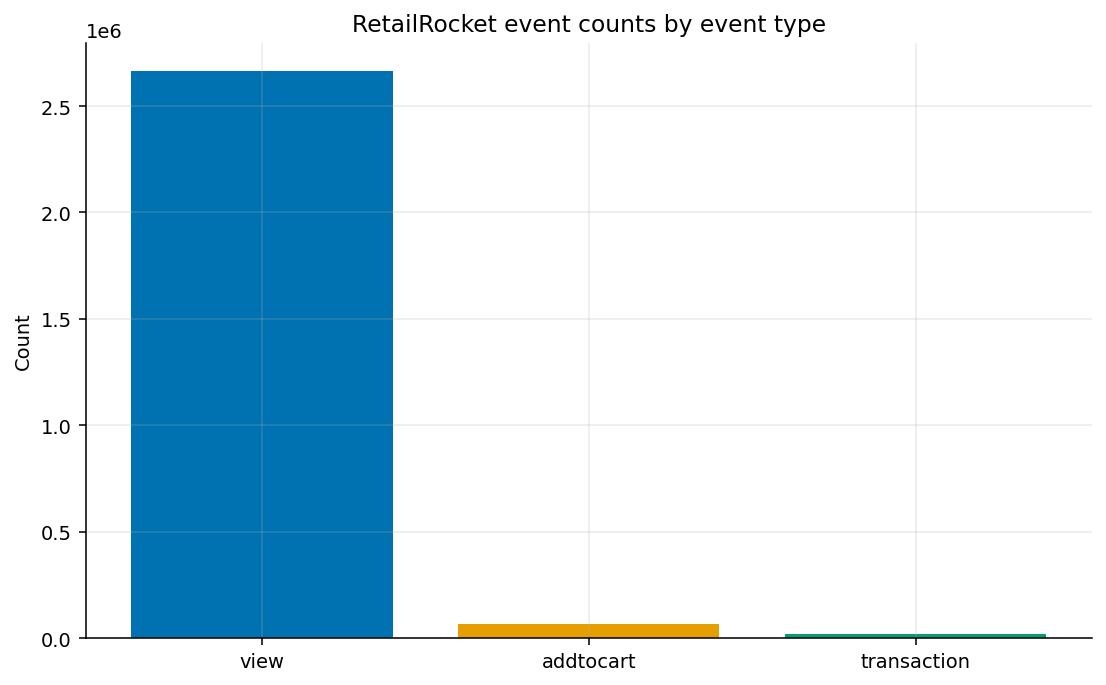

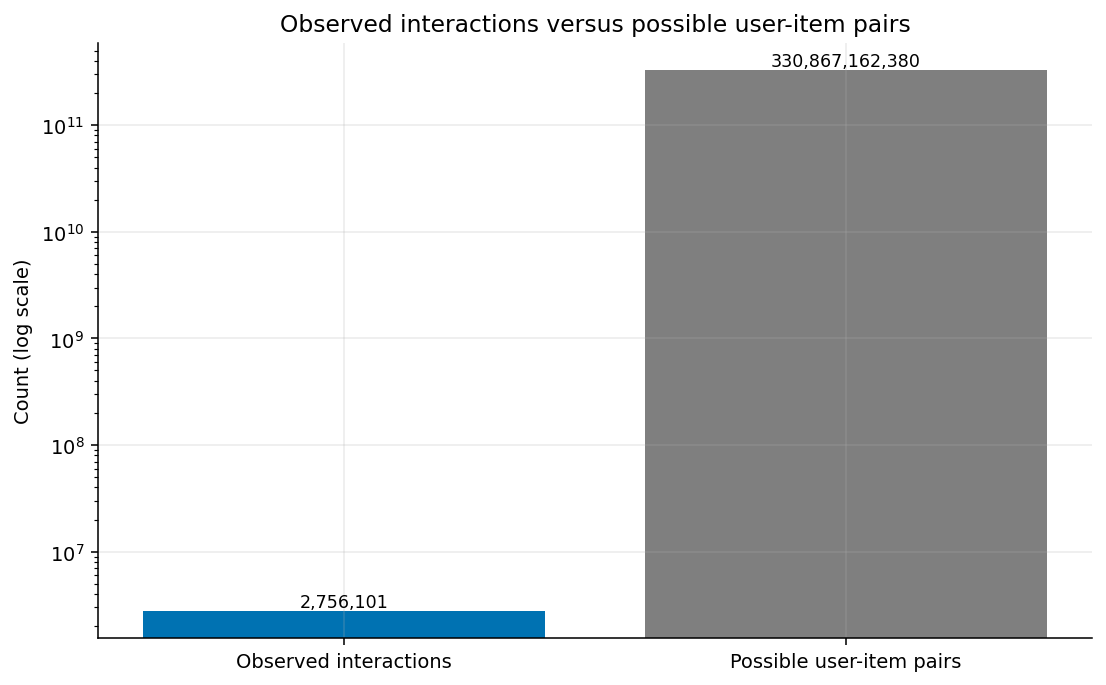

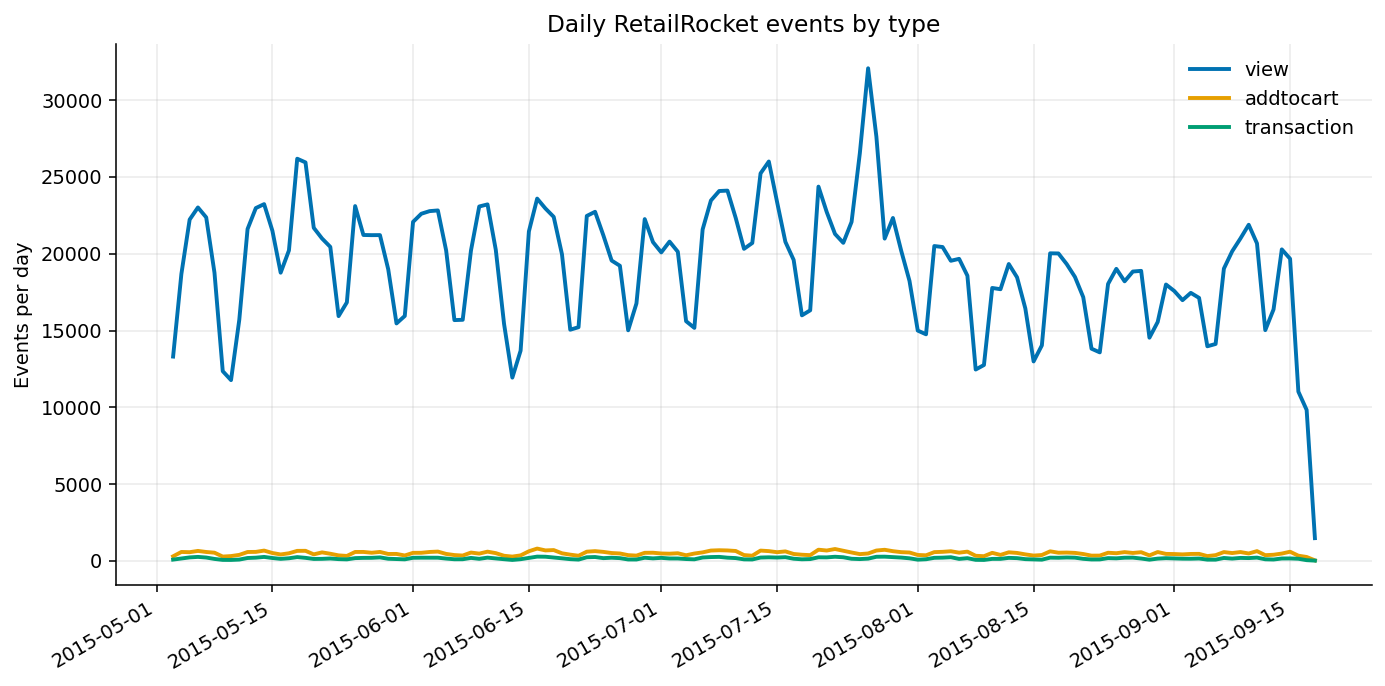

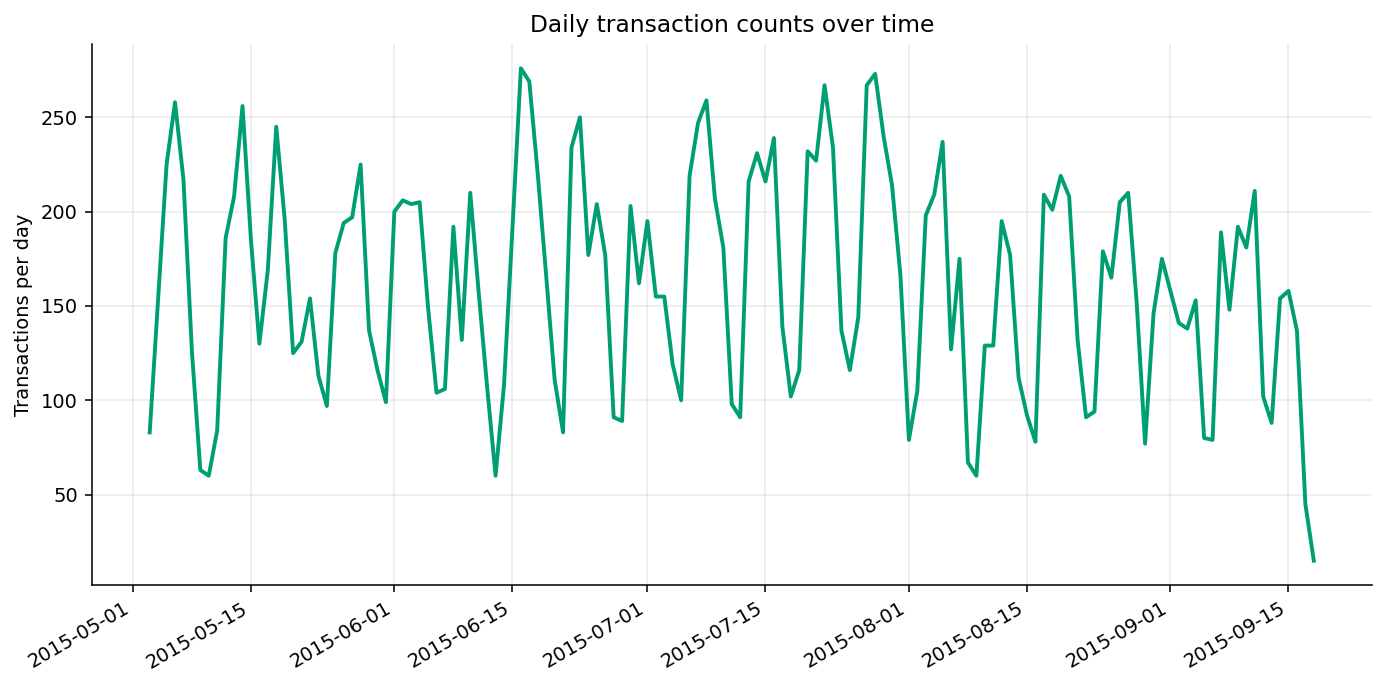

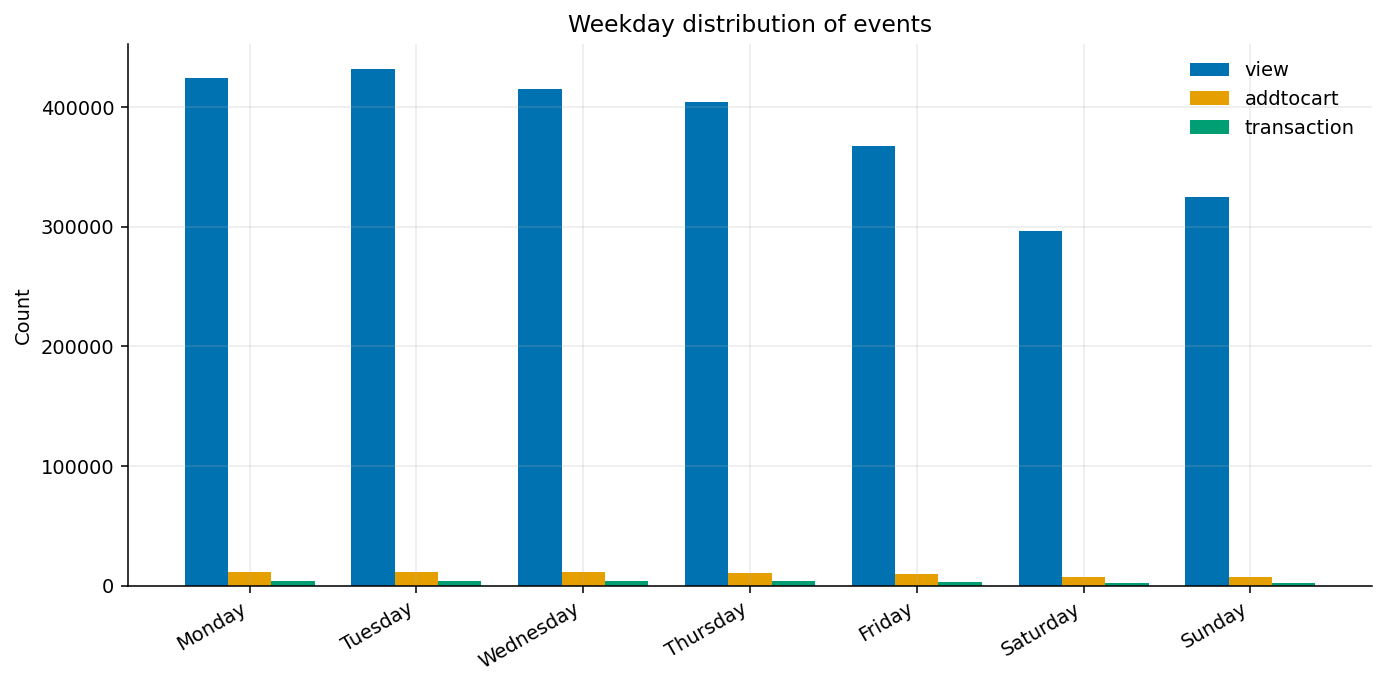

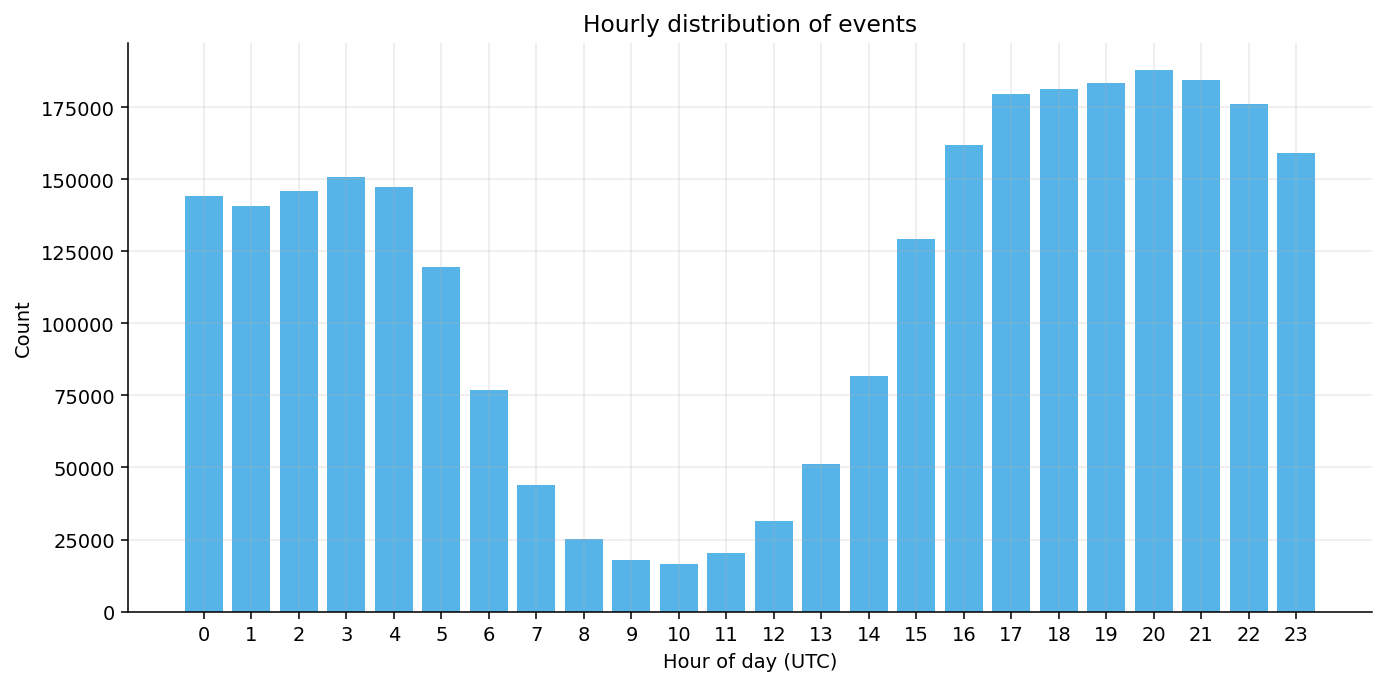

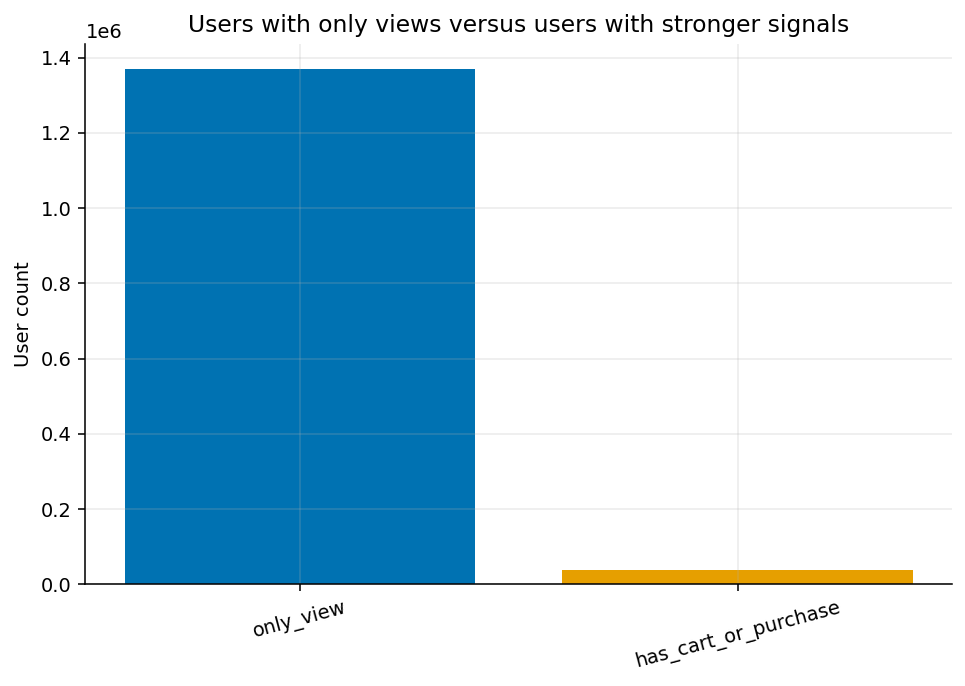

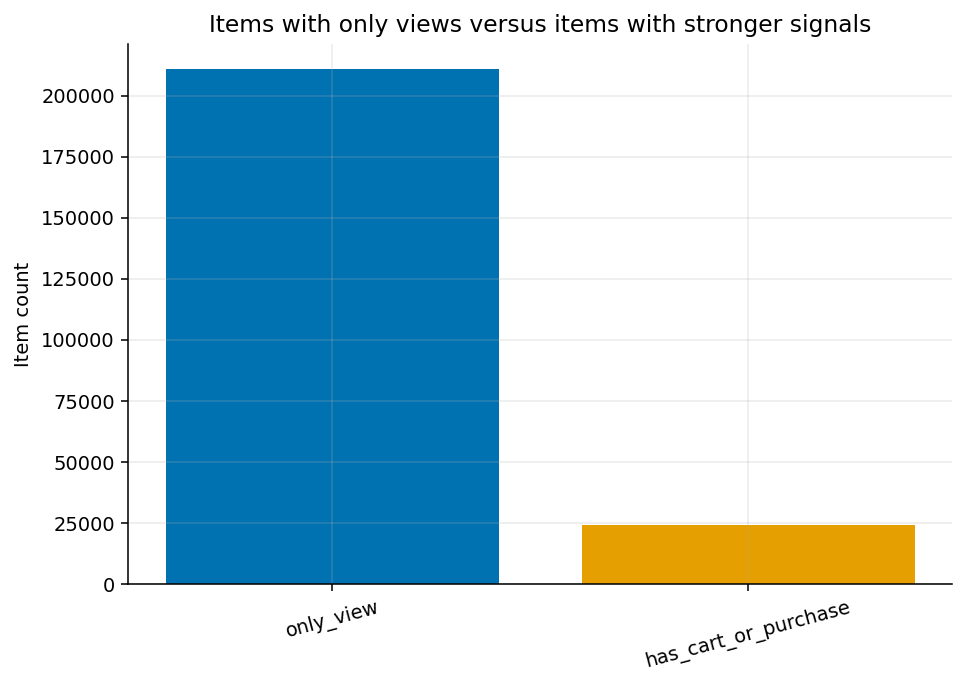

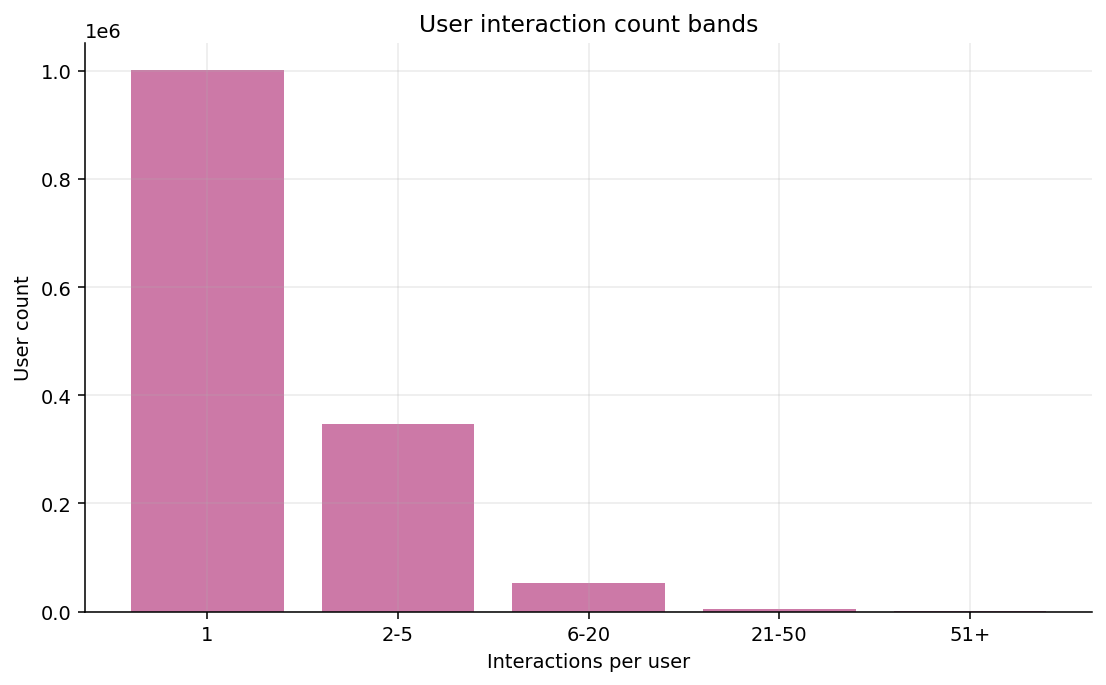

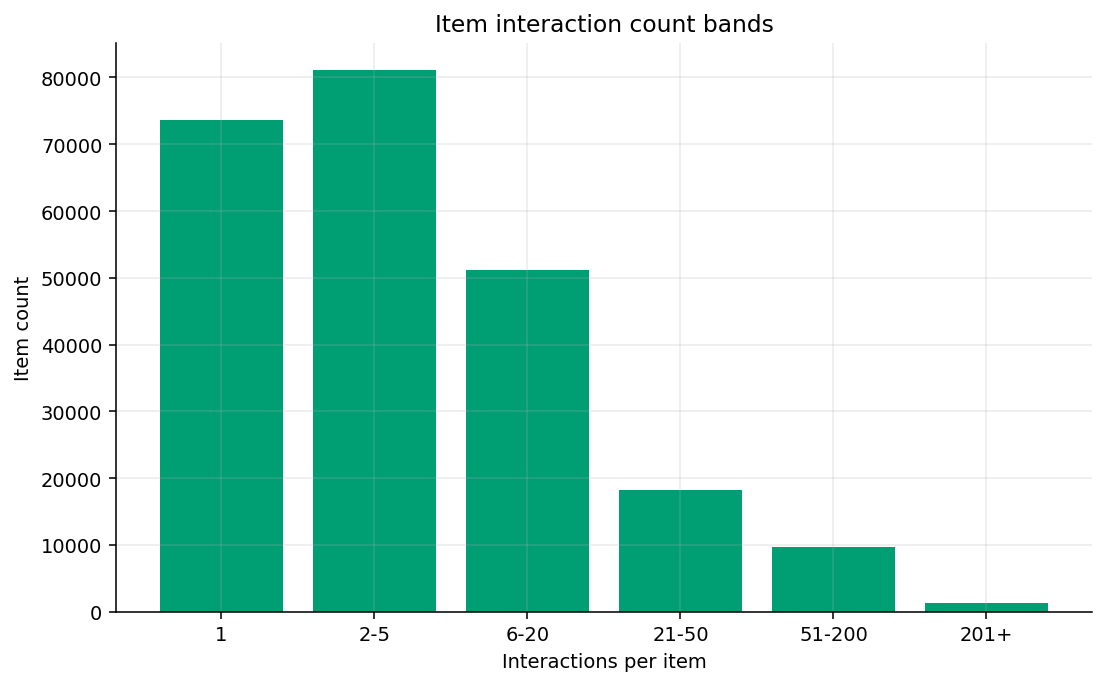

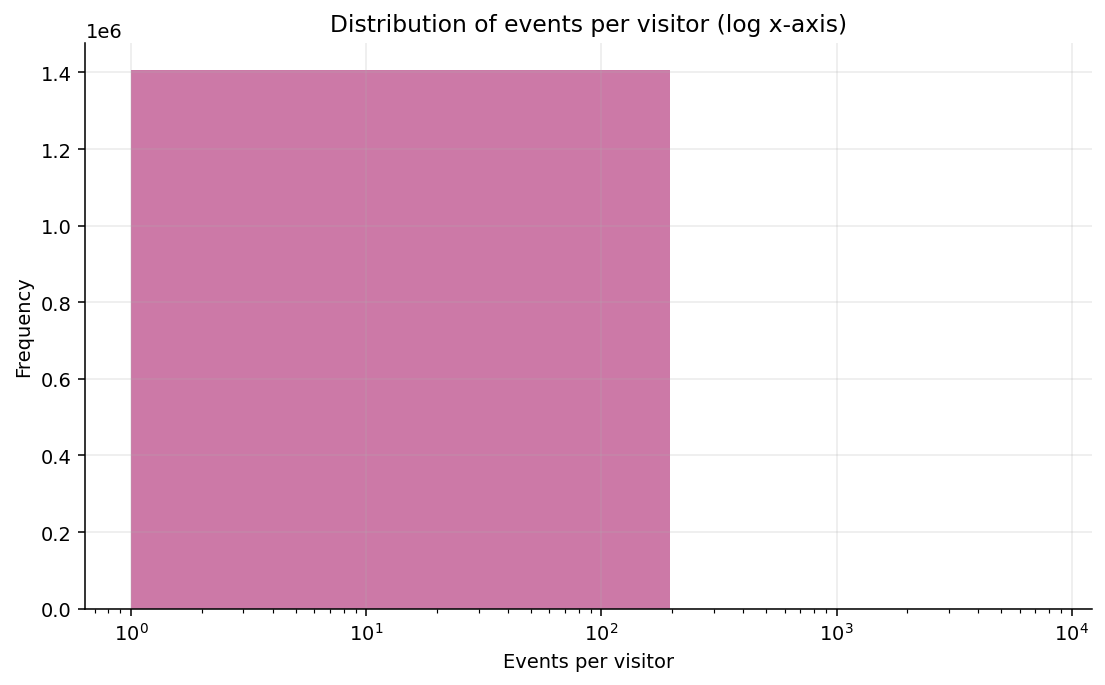

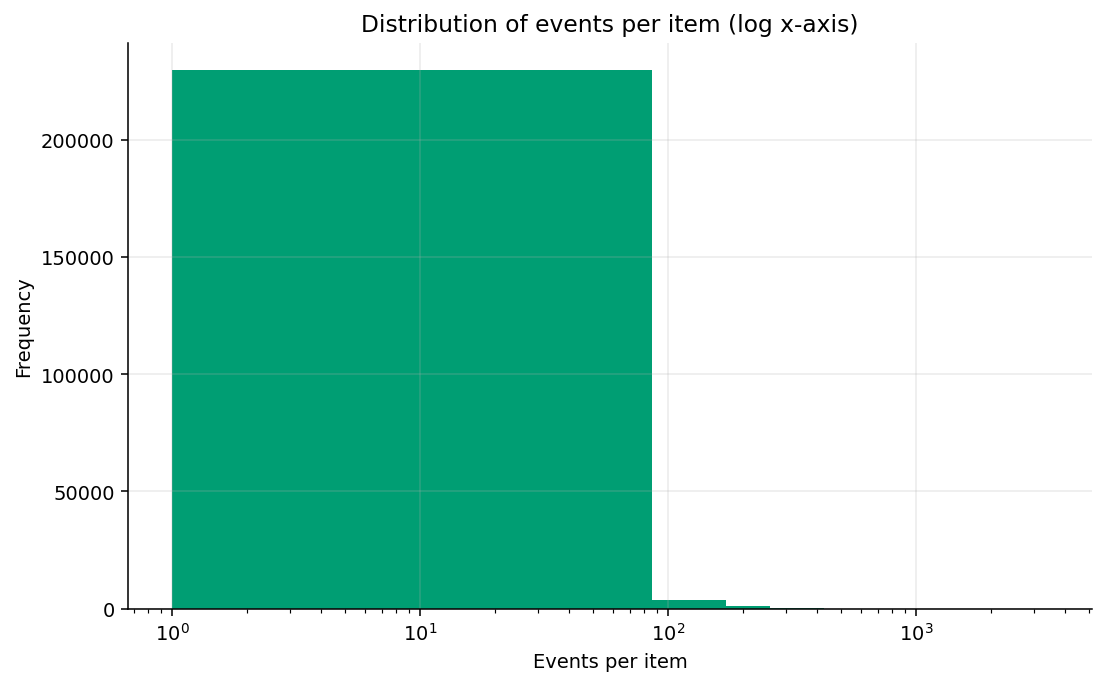

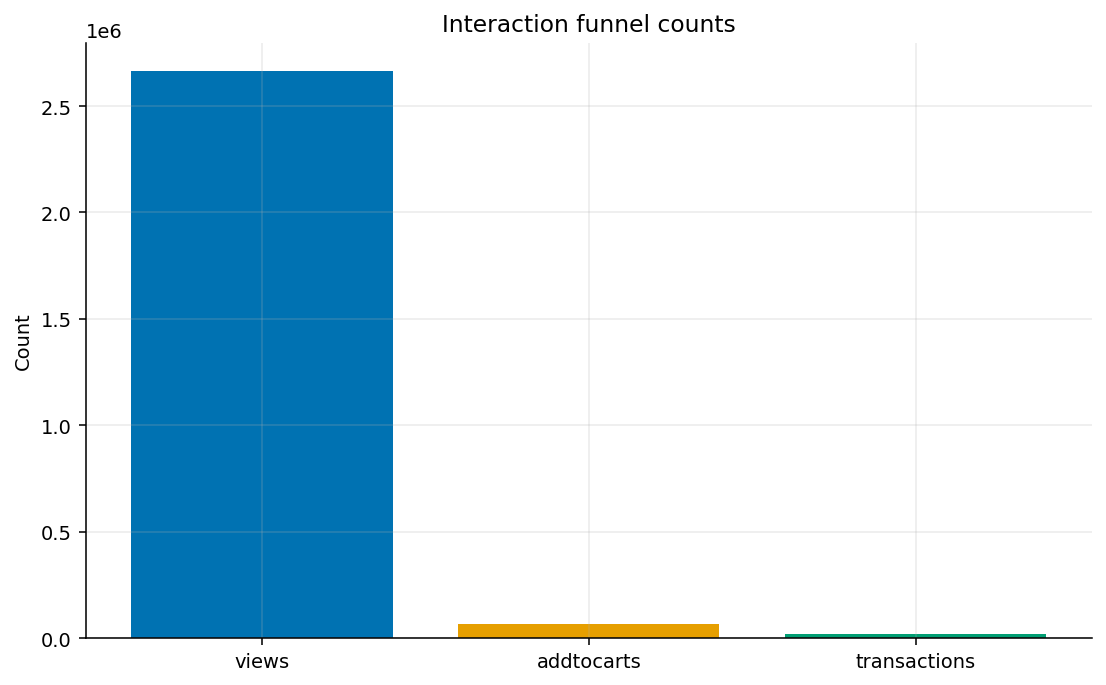

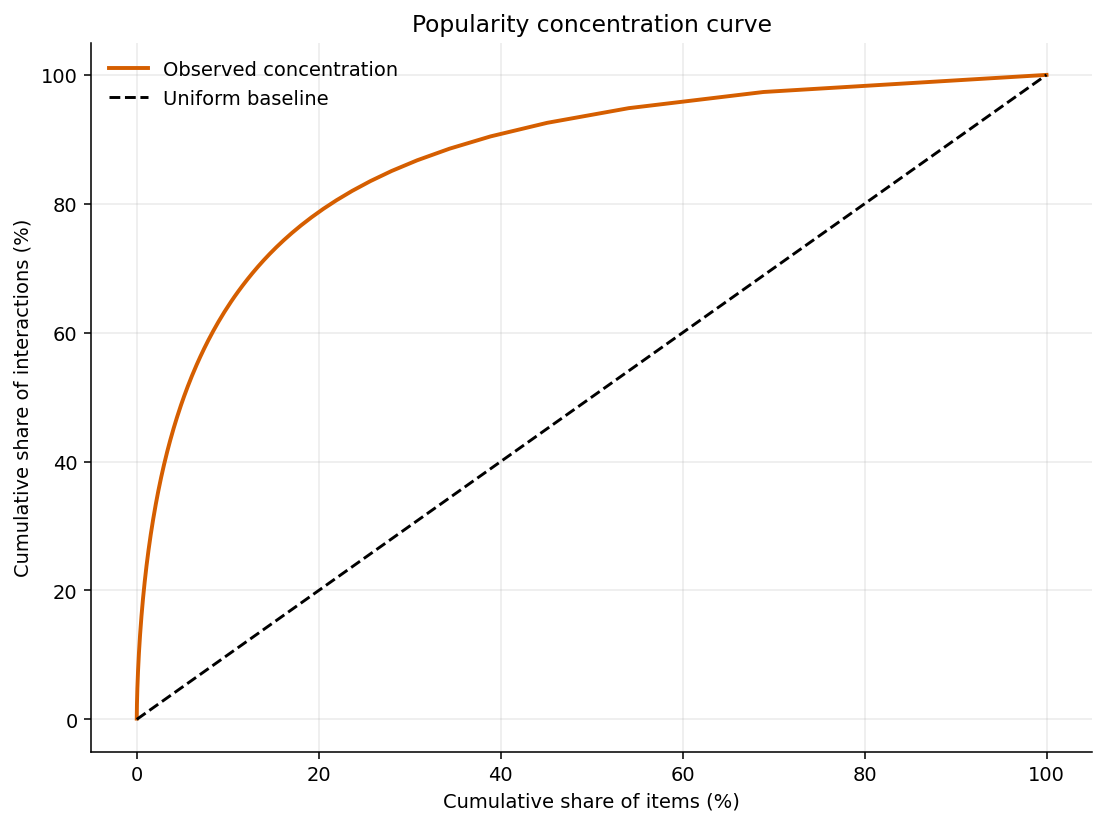

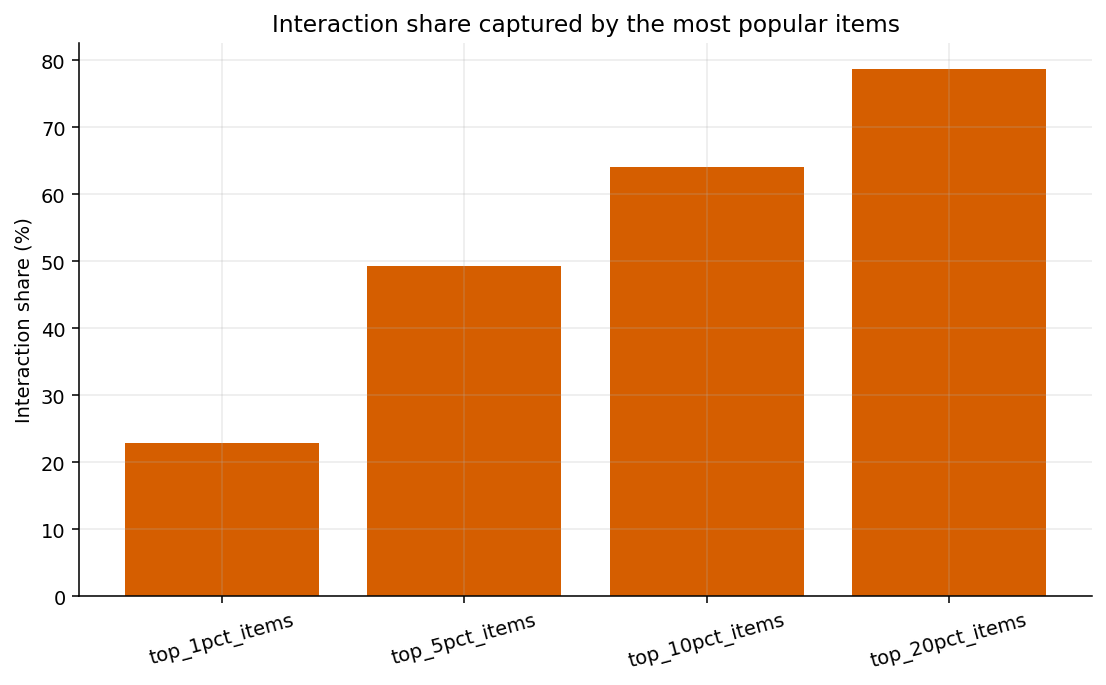

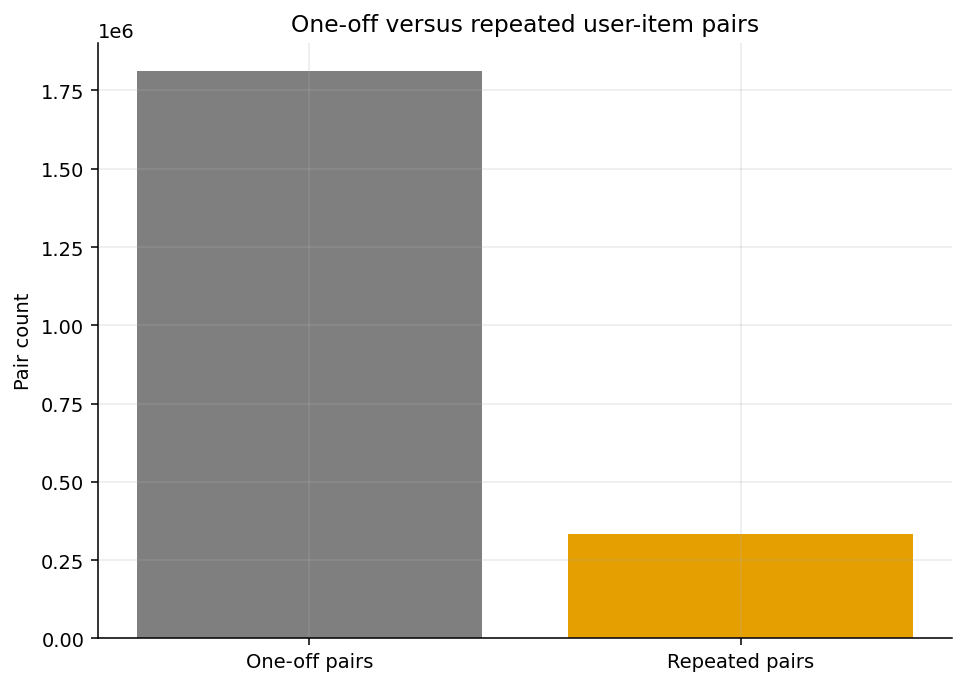

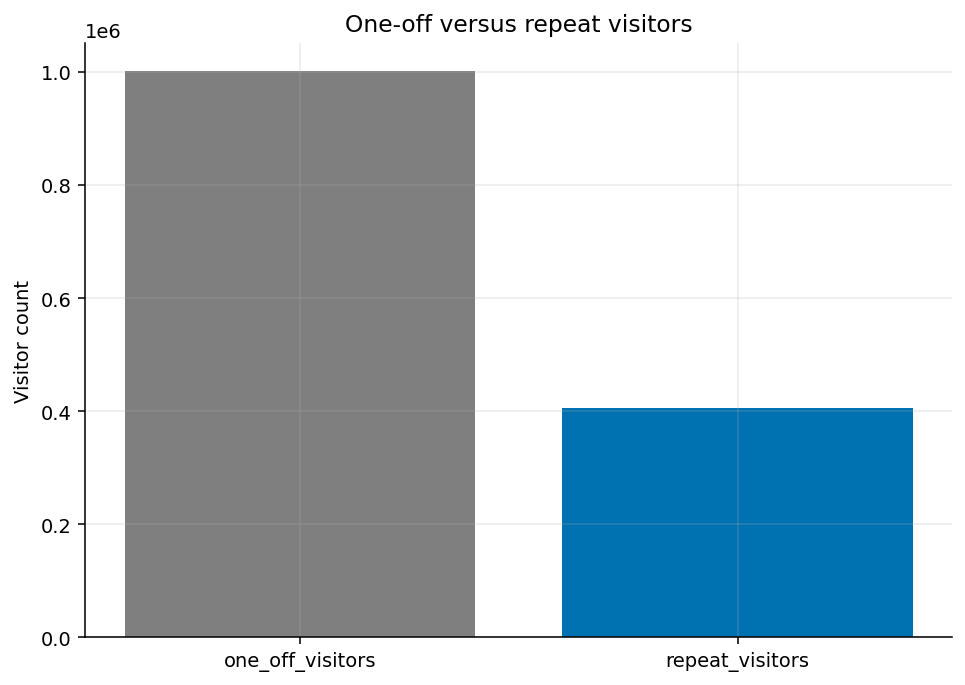

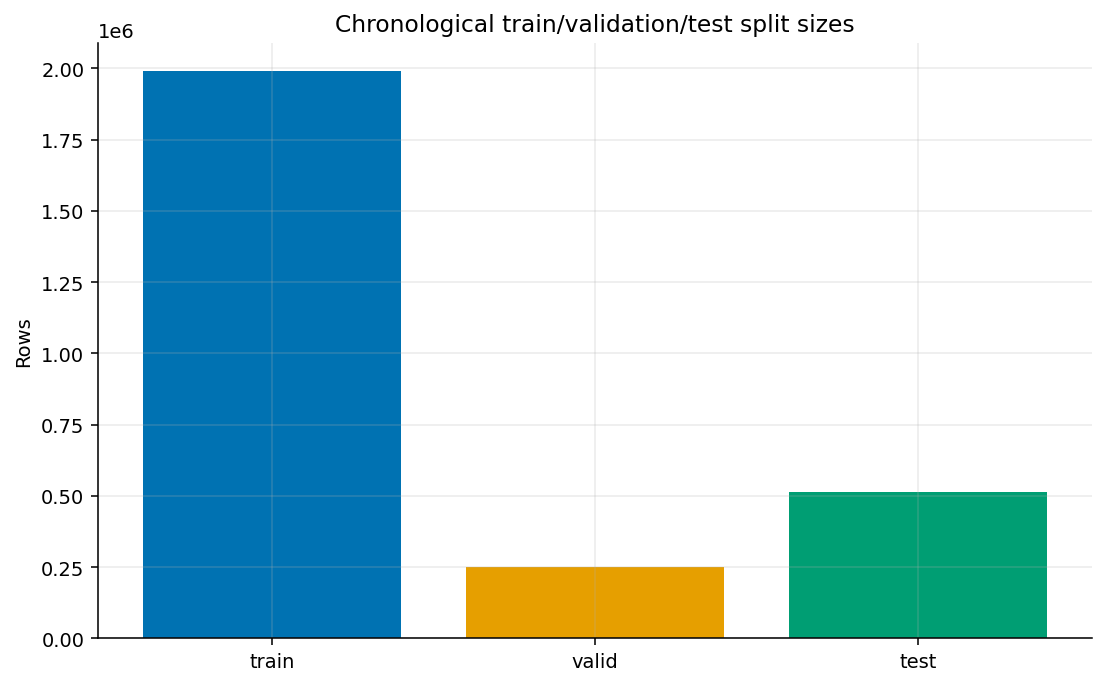

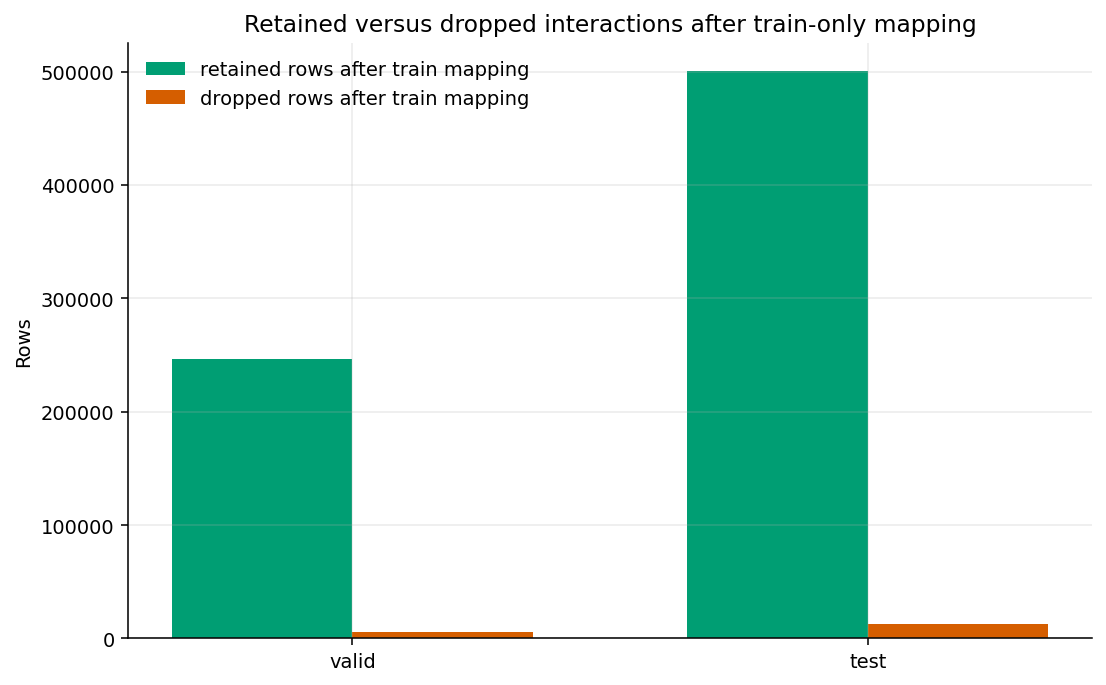

In [ ]:
# Plot overall event counts by interaction type.
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    event_type_counts["event"].astype(str),
    event_type_counts["count"],
    color=[EVENT_COLOURS.get(v, PALETTE["grey"]) for v in event_type_counts["event"].astype(str)],
)
ax.set_title("RetailRocket event counts by event type")
ax.set_ylabel("Count")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figures" / "event_type_counts.png", bbox_inches="tight")
plt.show()

# Compare the number of observed interactions against the total possible
# user-item combinations to illustrate sparsity.
sparsity_plot = pd.DataFrame(
    {
        "measure": ["Observed interactions", "Possible user-item pairs"],
        "count": [n_interactions, possible_pairs],
    }
)
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(sparsity_plot["measure"], sparsity_plot["count"], color=[PALETTE["blue"], PALETTE["grey"]])
ax.set_title("Observed interactions versus possible user-item pairs")
ax.set_ylabel("Count (log scale)")
ax.set_yscale("log")
for i, v in enumerate(sparsity_plot["count"]):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figures" / "sparsity_observed_vs_possible.png", bbox_inches="tight")
plt.show()

# Plot daily event volumes for each available event type.
daily_plot = daily_event_counts_by_type.copy()
fig, ax = plt.subplots(figsize=(10, 5))
for event_name in ["view", "addtocart", "transaction"]:
    if event_name in daily_plot.columns:
        ax.plot(daily_plot["event_date"], daily_plot[event_name], label=event_name, color=EVENT_COLOURS[event_name], linewidth=2)
ax.set_title("Daily RetailRocket events by type")
ax.set_ylabel("Events per day")
ax.legend(frameon=False)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figures" / "daily_events_by_type.png", bbox_inches="tight")
plt.show()

# Plot daily transaction counts to show purchasing activity over time.
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(daily_transactions["event_date"], daily_transactions["transaction_count"], color=EVENT_COLOURS["transaction"], linewidth=2)
ax.set_title("Daily transaction counts over time")
ax.set_ylabel("Transactions per day")
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figures" / "daily_transactions.png", bbox_inches="tight")
plt.show()

# Compare event volumes across weekdays for each event type.
weekday_plot = weekday_event_distribution.copy()
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(weekday_plot["weekday_name"]))
width = 0.26
for offset, event_name in zip([-width, 0, width], ["view", "addtocart", "transaction"]):
    if event_name in weekday_plot.columns:
        ax.bar(x + offset, weekday_plot[event_name], width=width, label=event_name, color=EVENT_COLOURS[event_name])
ax.set_xticks(x)
ax.set_xticklabels(weekday_plot["weekday_name"], rotation=30, ha="right")
ax.set_title("Weekday distribution of events")
ax.set_ylabel("Count")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figures" / "weekday_event_distribution.png", bbox_inches="tight")
plt.show()

# Show the total number of events recorded in each hour of the day.
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(hourly_event_distribution["event_hour"], hourly_event_distribution["total_events"], color=PALETTE["sky"])
ax.set_title("Hourly distribution of events")
ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel("Count")
ax.set_xticks(range(0, 24, 1))
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figures" / "hourly_event_distribution.png", bbox_inches="tight")
plt.show()

# Compare users with only view activity against users with stronger signals.
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(user_signal_summary["signal_class"], user_signal_summary["user_count"], color=[PALETTE["blue"], PALETTE["orange"]])
ax.set_title("Users with only views versus users with stronger signals")
ax.set_ylabel("User count")
ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figures" / "user_signal_summary.png", bbox_inches="tight")
plt.show()

# Compare items with only view activity against items with stronger signals.
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(item_signal_summary["signal_class"], item_signal_summary["item_count"], color=[PALETTE["blue"], PALETTE["orange"]])
ax.set_title("Items with only views versus items with stronger signals")
ax.set_ylabel("Item count")
ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figures" / "item_signal_summary.png", bbox_inches="tight")
plt.show()

# Plot the distribution of users across interaction-count bands.
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(user_interaction_band_summary["interaction_band"].astype(str), user_interaction_band_summary["user_count"], color=PALETTE["purple"])
ax.set_title("User interaction count bands")
ax.set_xlabel("Interactions per user")
ax.set_ylabel("User count")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figures" / "user_interaction_band_summary.png", bbox_inches="tight")
plt.show()

# Plot the distribution of items across interaction-count bands.
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(item_interaction_band_summary["interaction_band"].astype(str), item_interaction_band_summary["item_count"], color=PALETTE["green"])
ax.set_title("Item interaction count bands")
ax.set_xlabel("Interactions per item")
ax.set_ylabel("Item count")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figures" / "item_interaction_band_summary.png", bbox_inches="tight")
plt.show()

# Plot the distribution of event counts per visitor on a logarithmic x-axis.
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(visitor_events["events_per_visitor"], bins=40, color=PALETTE["purple"])
ax.set_xscale("log")
ax.set_title("Distribution of events per visitor (log x-axis)")
ax.set_xlabel("Events per visitor")
ax.set_ylabel("Frequency")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figures" / "visitor_activity_distribution.png", bbox_inches="tight")
plt.show()

# Plot the distribution of event counts per item on a logarithmic x-axis.
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(item_events["events_per_item"], bins=40, color=PALETTE["green"])
ax.set_xscale("log")
ax.set_title("Distribution of events per item (log x-axis)")
ax.set_xlabel("Events per item")
ax.set_ylabel("Frequency")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figures" / "item_activity_distribution.png", bbox_inches="tight")
plt.show()

# Plot the main interaction funnel from views to carts to transactions.
funnel_plot = ratio_summary.melt(value_vars=["views", "addtocarts", "transactions"], var_name="stage", value_name="count")
funnel_colours = [EVENT_COLOURS["view"], EVENT_COLOURS["addtocart"], EVENT_COLOURS["transaction"]]
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(funnel_plot["stage"], funnel_plot["count"], color=funnel_colours)
ax.set_title("Interaction funnel counts")
ax.set_ylabel("Count")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figures" / "interaction_funnel_counts.png", bbox_inches="tight")
plt.show()

# Plot the cumulative share of interactions captured by increasingly larger
# shares of items, alongside a uniform baseline.
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(
    item_popularity["cumulative_item_share_pct"],
    item_popularity["cumulative_interaction_share_pct"],
    color=PALETTE["red"],
    linewidth=2,
    label="Observed concentration",
)
ax.plot([0, 100], [0, 100], linestyle="--", color=PALETTE["black"], linewidth=1.5, label="Uniform baseline")
ax.set_title("Popularity concentration curve")
ax.set_xlabel("Cumulative share of items (%)")
ax.set_ylabel("Cumulative share of interactions (%)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figures" / "popularity_concentration_curve.png", bbox_inches="tight")
plt.show()

# Show how much interaction volume is captured by the most popular item bands.
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(top_item_share_summary["top_item_share_band"], top_item_share_summary["interaction_share_pct"], color=PALETTE["red"])
ax.set_title("Interaction share captured by the most popular items")
ax.set_ylabel("Interaction share (%)")
ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figures" / "top_item_share_summary.png", bbox_inches="tight")
plt.show()

# Compare one-off user-item pairs with repeated user-item pairs.
repeat_pair_plot = pd.DataFrame(
    {
        "pair_group": ["One-off pairs", "Repeated pairs"],
        "count": [
            int(pair_repeat_summary["unique_user_item_pairs"].iloc[0] - pair_repeat_summary["repeated_user_item_pairs"].iloc[0]),
            int(pair_repeat_summary["repeated_user_item_pairs"].iloc[0]),
        ],
    }
)
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(repeat_pair_plot["pair_group"], repeat_pair_plot["count"], color=[PALETTE["grey"], PALETTE["orange"]])
ax.set_title("One-off versus repeated user-item pairs")
ax.set_ylabel("Pair count")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figures" / "repeat_pair_summary.png", bbox_inches="tight")
plt.show()

# Compare one-off visitors with repeat visitors.
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(visitor_repeat_summary["visitor_group"], visitor_repeat_summary["visitor_count"], color=[PALETTE["grey"], PALETTE["blue"]])
ax.set_title("One-off versus repeat visitors")
ax.set_ylabel("Visitor count")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figures" / "visitor_repeat_summary.png", bbox_inches="tight")
plt.show()

# Plot the number of rows assigned to each chronological split.
fig, ax = plt.subplots(figsize=(8, 5))
split_order = ["train", "valid", "test"]
split_plot = chronological_split_summary.set_index("split").reindex(split_order).reset_index()
ax.bar(split_plot["split"], split_plot["rows"], color=[PALETTE["blue"], PALETTE["orange"], PALETTE["green"]])
ax.set_title("Chronological train/validation/test split sizes")
ax.set_ylabel("Rows")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figures" / "chronological_split_sizes.png", bbox_inches="tight")
plt.show()

# Compare retained and dropped rows after applying train-only mappings.
mapping_plot = split_mapping_diagnostics.melt(
    id_vars="split",
    value_vars=["retained_rows_after_train_mapping", "dropped_rows_after_train_mapping"],
    var_name="mapping_result",
    value_name="row_count",
)
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(split_mapping_diagnostics["split"]))
width = 0.35
result_order = ["retained_rows_after_train_mapping", "dropped_rows_after_train_mapping"]
result_colours = [PALETTE["green"], PALETTE["red"]]
for i, (result_name, colour) in enumerate(zip(result_order, result_colours)):
    subset = mapping_plot.loc[mapping_plot["mapping_result"] == result_name]
    ax.bar(x + (i - 0.5) * width, subset["row_count"], width=width, label=result_name.replace("_", " "), color=colour)
ax.set_xticks(x)
ax.set_xticklabels(split_mapping_diagnostics["split"])
ax.set_title("Retained versus dropped interactions after train-only mapping")
ax.set_ylabel("Rows")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figures" / "split_mapping_diagnostics.png", bbox_inches="tight")
plt.show()

## 8. Export all tables into one Excel workbook

In [ ]:
# Collect all generated summary and diagnostic tables in one dictionary for
# convenient inspection, export, or downstream reuse.
all_tables = {
    "dataset_summary": dataset_summary,
    "event_type_counts": event_type_counts,
    "daily_event_counts_by_type": daily_event_counts_by_type,
    "monthly_activity_summary": monthly_activity_summary,
    "visitor_activity_distribution_summary": visitor_activity_distribution_summary,
    "item_activity_distribution_summary": item_activity_distribution_summary,
    "sparsity_summary": sparsity_summary,
    "user_signal_summary": user_signal_summary,
    "item_signal_summary": item_signal_summary,
    "user_interaction_band_summary": user_interaction_band_summary,
    "item_interaction_band_summary": item_interaction_band_summary,
    "daily_total_events": daily_total_events,
    "daily_transactions": daily_transactions,
    "weekday_event_distribution": weekday_event_distribution,
    "hourly_event_distribution": hourly_event_distribution,
    "ratio_summary": ratio_summary,
    "top_item_share_summary": top_item_share_summary,
    "pair_repeat_summary": pair_repeat_summary,
    "visitor_repeat_summary": visitor_repeat_summary,
    "chronological_split_summary": chronological_split_summary,
    "split_event_type_counts": split_event_type_counts,
    "split_mapping_diagnostics": split_mapping_diagnostics,
}

# Print the output locations for saved tabular and figure artefacts.
print("Saved tables to:", OUTPUT_DIR / "tables")
print("Saved figures to:", OUTPUT_DIR / "figures")

# Preview the chronological split summary table.
chronological_split_summary

Saved tables to: output\dataset_audit\tables
Saved figures to: output\dataset_audit\figures


,split,rows,unique_users,unique_items,start_timestamp_utc,end_timestamp_utc
0,test,513257,406020,114068,2015-05-03 03:00:29.427000+00:00,2015-09-18 02:59:47.788000+00:00
1,train,1990913,1407580,220008,2015-05-03 03:00:04.384000+00:00,2015-09-18 02:59:41.778000+00:00
2,valid,251931,200028,72821,2015-05-03 03:00:26.228000+00:00,2015-09-18 02:57:55.667000+00:00
